# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon | 5054251004 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [28]:
# Import library yang dibutuhkan.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.

data = pd.read_csv('/content/insurance.csv')
print("Ukuran dataset:", data.shape)

Ukuran dataset: (1338, 7)


In [ ]:
# Tampilkan beberapa baris pertama dataset.

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Tampilkan informasi dataset.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Periksa missing value.

print("Baris duplikat :",(data.duplicated().sum()))
print("Jumlah baris kosong:")
data.isna().sum()[data.isna().sum()>0]

Baris duplikat : 1
Jumlah baris kosong:


,0


In [ ]:
# Tampilkan statistik deskriptif fitur numerik.

kolom_numerik = data.select_dtypes(include=[np.number]).columns.tolist()
data[kolom_numerik].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.0,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.0,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.0,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


In [ ]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.

kolom_kategori = data.select_dtypes(exclude=[np.number]).columns.tolist()
for kolom in kolom_kategori:
  print(data[kolom].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


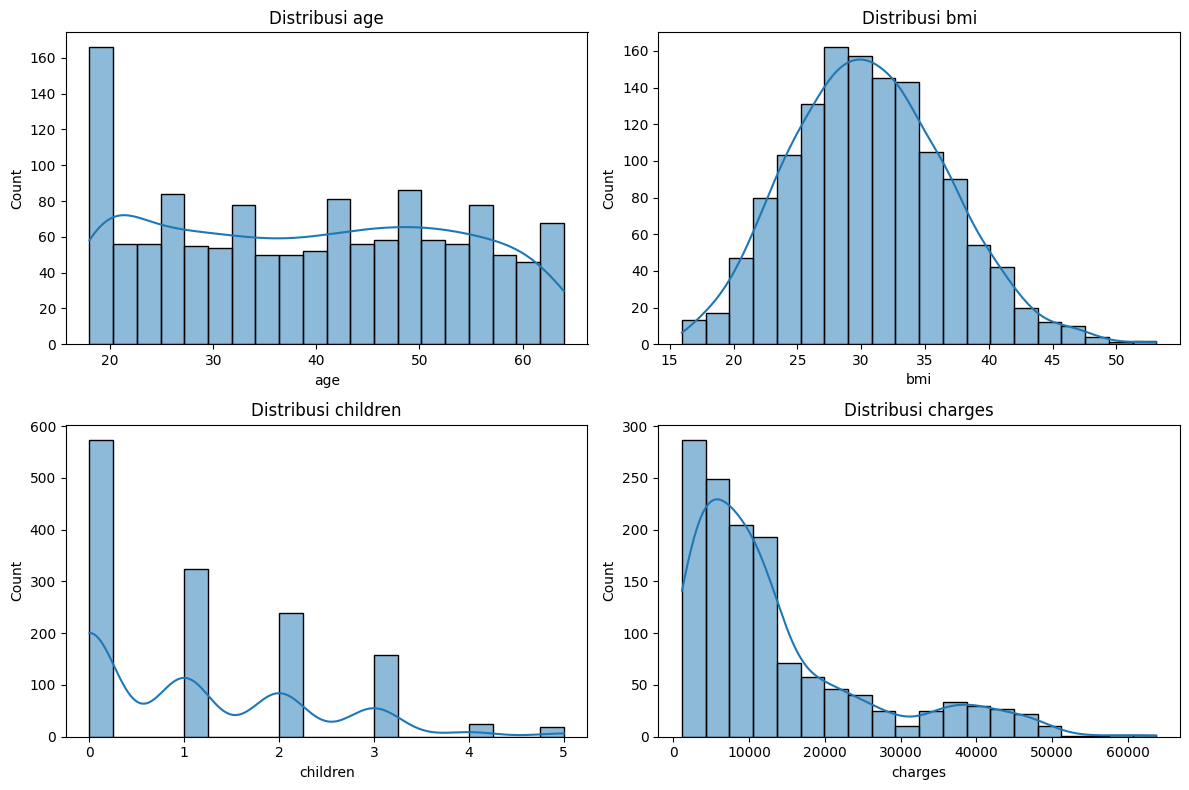

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(kolom_numerik):
  plt.subplot(2, 2, i + 1)
  sns.histplot(data[col], kde=True, bins=20)
  plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

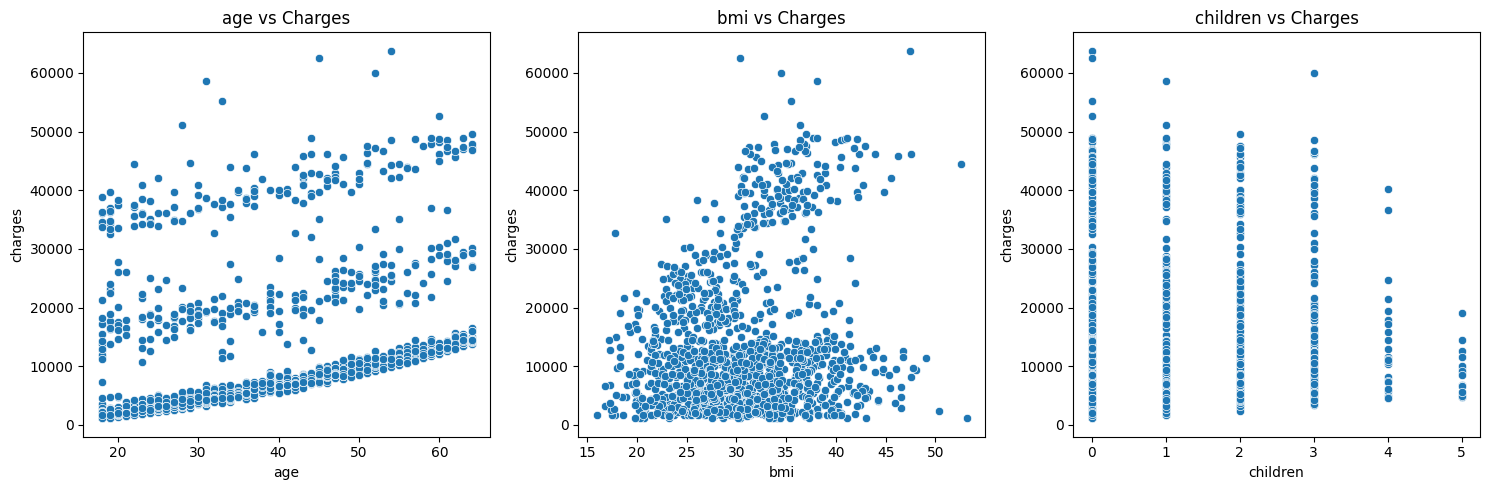

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['age', 'bmi', 'children']):
  plt.subplot(1, 3, i + 1)
  sns.scatterplot(data=data, x=col, y='charges')
  plt.title(f"{col} vs Charges")
plt.tight_layout()
plt.show()

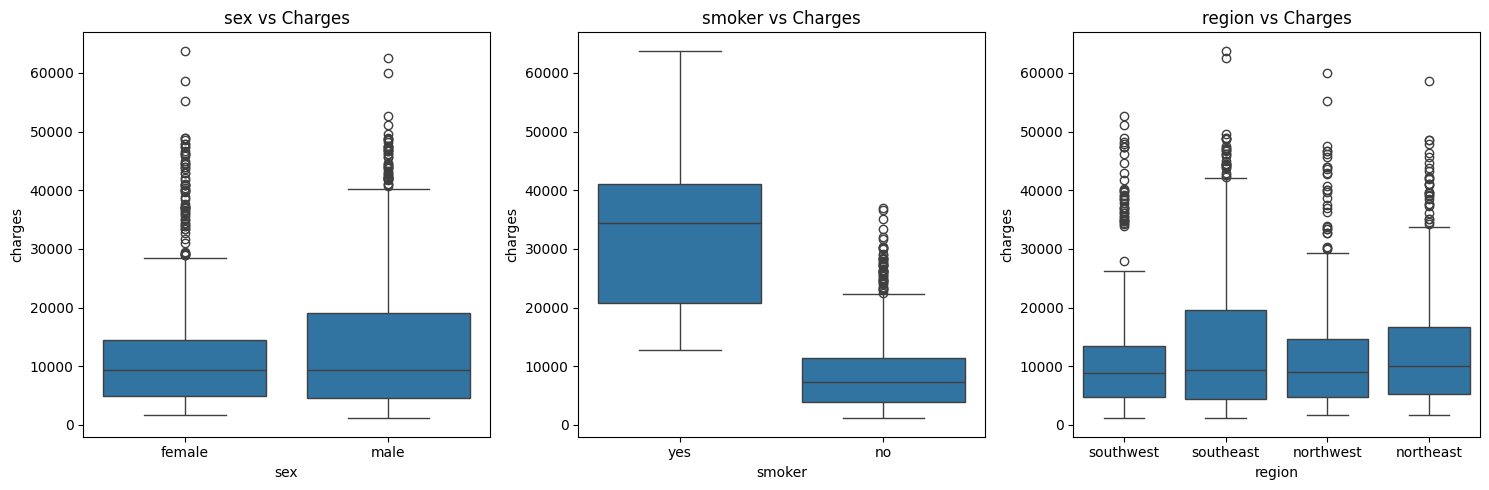

In [24]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(kolom_kategori):
  plt.subplot(1, 3, i + 1)
  sns.boxplot(data=data, x=col, y='charges')
  plt.title(f"{col} vs Charges")
plt.tight_layout()
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [25]:
data_clean = data.drop_duplicates().reset_index(drop=True)

In [26]:
# Pisahkan fitur (X) dan target (y).

X = data_clean.drop(columns=['charges'])
y = data_clean['charges']

In [27]:
# Bagi data menjadi train set dan test set.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Identifikasi kolom numerik dan kategorikal.

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

In [30]:
# Buat preprocessing untuk fitur numerik dan kategorikal.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [32]:
# Inisialisasi dan latih Linear Regression.

from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [33]:
# Lakukan prediksi pada test set.

y_pred_lr = lr_pipeline.predict(X_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [36]:
# Buat fitur polynomial dan latih model.

from sklearn.preprocessing import PolynomialFeatures

num_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

poly_pipeline = Pipeline([
    ('prep', preprocessor_poly),
    ('model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [37]:
# Lakukan prediksi pada test set.

y_pred_poly = poly_pipeline.predict(X_test)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [38]:
# Inisialisasi dan latih Ridge Regression.

from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Ridge())])

In [39]:
# Lakukan prediksi pada test set.

y_pred_ridge = ridge_pipeline.predict(X_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [40]:
# Inisialisasi dan latih Lasso Regression.

from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', Lasso(alpha=1.0))
])

lasso_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Lasso())])

In [41]:
# Lakukan prediksi pada test set.

y_pred_lasso = lasso_pipeline.predict(X_test)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [42]:
# Inisialisasi dan latih Decision Tree Regressor.

from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [43]:
# Lakukan prediksi pada test set.

y_pred_dt = dt_pipeline.predict(X_test)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [44]:
# Inisialisasi dan latih SVR.

from sklearn.svm import SVR

svr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', SVR(C=1000, epsilon=0.1))
])

svr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', SVR(C=1000))])

In [45]:
# Lakukan prediksi pada test set.

y_pred_svr = svr_pipeline.predict(X_test)

# 4. Evaluasi Model

In [54]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_pred = {
    'Linear Regression': y_pred_lr,
    'Polynomial Regression': y_pred_poly,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'SVR': y_pred_svr
}

results = []
for name, y_pred in models_pred.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
1,Polynomial Regression,4404.321297,3.724430e+07,6102.811232,0.797317
2,Ridge,4193.891909,3.566313e+07,5971.861741,0.805921
3,Lasso,4177.778109,3.549317e+07,5957.614852,0.806846
4,Decision Tree,2804.811633,3.495303e+07,5912.108673,0.809786
5,SVR,4284.919611,8.646563e+07,9298.689455,0.529454


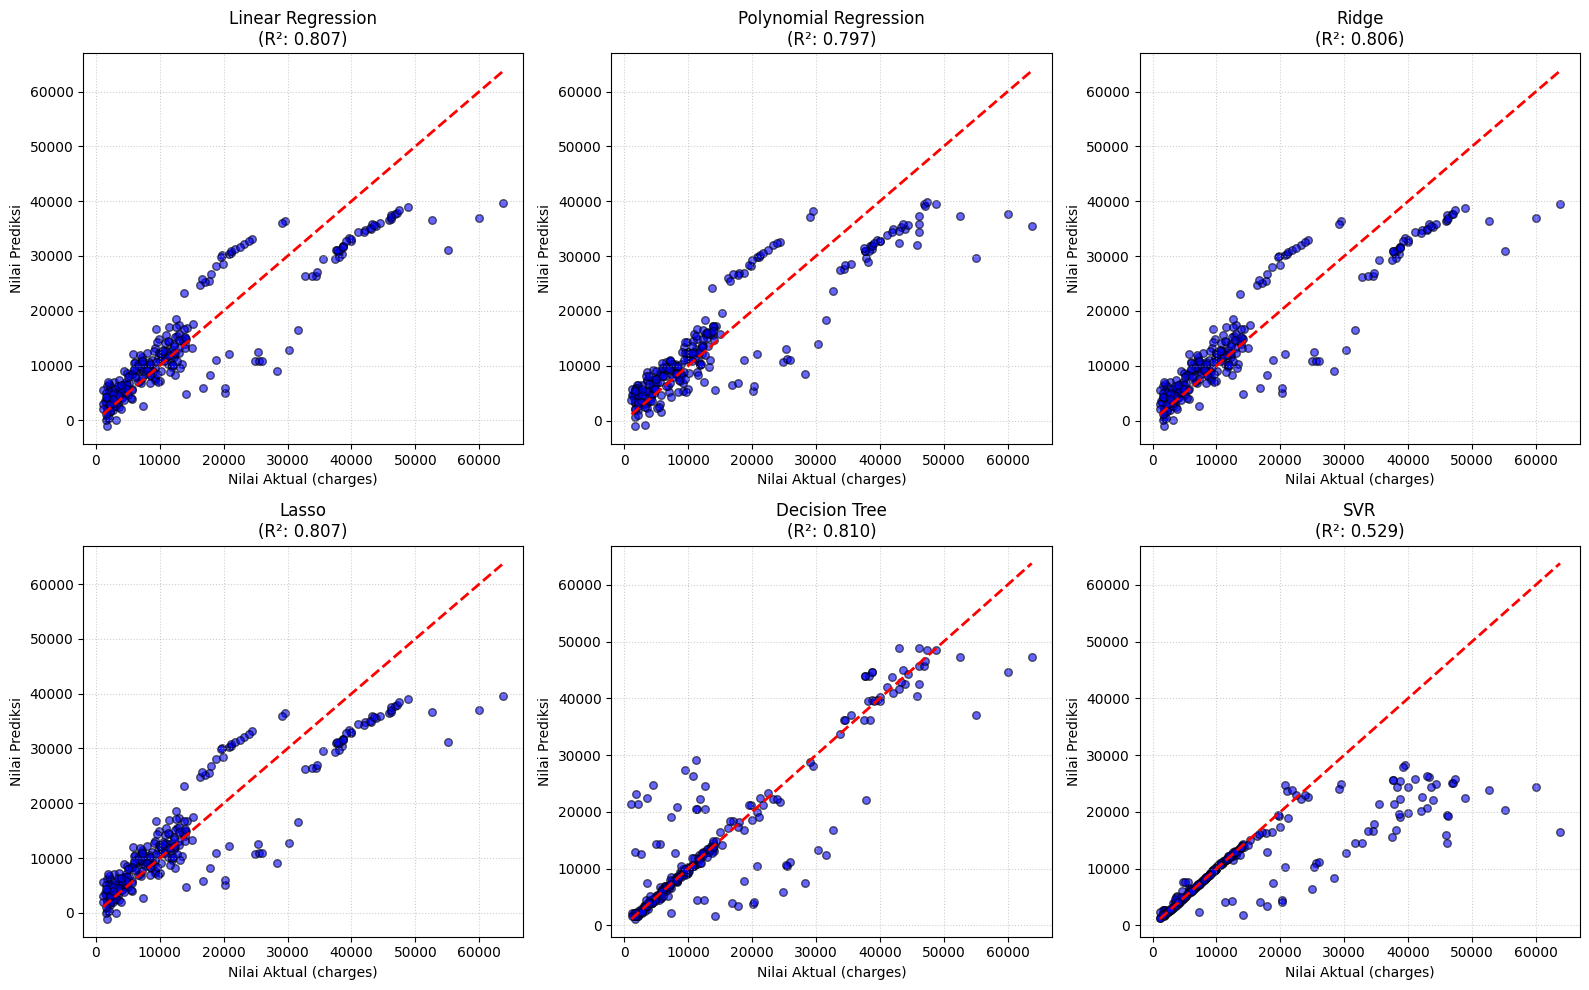

In [55]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_pred.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k', s=30)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{name}\n(R²: {results_df.loc[results_df["Model"]==name, "R²"].values[0]:.3f})')
    ax.set_xlabel('Nilai Aktual (charges)')
    ax.set_ylabel('Nilai Prediksi')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Eksperimen Tambahan

In [59]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# 1. Tuning Hyperparameter dengan GridSearchCV
# ==========================================

# A. SVR Tuning
svr_pipe = Pipeline([('prep', preprocessor), ('model', SVR())])
svr_params = {
    'model__kernel': ['rbf', 'poly', 'linear'],
    'model__C': [1000, 5000, 10000],
    'model__gamma': ['scale', 0.01, 0.1]
}
grid_svr = GridSearchCV(svr_pipe, svr_params, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

# B. Ridge Tuning
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

# C. Lasso Tuning
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso())])
lasso_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_lasso = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

# D. Decision Tree Tuning
dt_pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=42))])
dt_params = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(dt_pipe, dt_params, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

# ==========================================
# 2. Evaluasi Hasil Setelah Tuning
# ==========================================

tuned_models = {
    'SVR (Tuned)': grid_svr.best_estimator_,
    'Ridge (Tuned)': grid_ridge.best_estimator_,
    'Lasso (Tuned)': grid_lasso.best_estimator_,
    'Decision Tree (Tuned)': grid_dt.best_estimator_
}

results_tuned = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results_tuned.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })

df_tuned = pd.DataFrame(results_tuned)

print("--- PARAMETER TERBAIK HASIL TUNING ---")
print("SVR Best Params          :", grid_svr.best_params_)
print("Decision Tree Best Params:", grid_dt.best_params_)
print("Ridge Best Alpha         :", grid_ridge.best_params_)
print("Lasso Best Alpha         :", grid_lasso.best_params_)

print("\n--- PERBANDINGAN HASIL SETELAH TUNING ---")
print(df_tuned.to_string(index=False))

--- PARAMETER TERBAIK HASIL TUNING ---
SVR Best Params          : {'model__C': 10000, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Decision Tree Best Params: {'model__max_depth': 5, 'model__min_samples_split': 10}
Ridge Best Alpha         : {'model__alpha': 1.0}
Lasso Best Alpha         : {'model__alpha': 10.0}

--- PERBANDINGAN HASIL SETELAH TUNING ---
                Model         MAE          MSE        RMSE       R²
          SVR (Tuned) 1992.480701 2.402130e+07 4901.152488 0.869276
        Ridge (Tuned) 4193.891909 3.566313e+07 5971.861741 0.805921
        Lasso (Tuned) 4184.381085 3.563632e+07 5969.616715 0.806067
Decision Tree (Tuned) 2656.839079 1.946166e+07 4411.537636 0.894090


# 5. Analisis

### 1. Pengaruh Preprocessing Data
* **Feature Scaling (`StandardScaler`):**
  * Fitur numerik (`age`, `bmi`, `children`) memiliki rentang skala yang berbeda jauh. Scaling sangat penting untuk SVR karena berbasis jarak. Tanpa scaling, variabel berskala besar akan mendominasi perhitungan margin.
  * Pada model ter-regularisasi (Ridge & Lasso), scaling memastikan penalti koefisien diterapkan secara adil pada semua fitur.
* **Categorical Encoding (`OneHotEncoder`):**
  * Penggunaan `drop_first=True` pada data kategorikal (`sex`, `smoker`, `region`) penting untuk menghindari multicollinearity, terutama bagi model linier (Linear Regression, Ridge, Lasso).
* **Karakteristik Decision Tree terhadap Preprocessing:**
  * Decision Tree bersifat scale-invariant. Scaling tidak mengubah hasil splitting node pada pohon keputusan.

---

### 2. Perbandingan Performa Model Baseline (Default Hyperparameter)
Berdasarkan pengujian awal menggunakan konfigurasi standar Scikit-Learn:

* **Decision Tree** mencatatkan performa terbaik pada baseline dengan MAE Rp 2.804,81 dan $R^2 = 0.8098$. Hal ini disebabkan oleh kemampuan pohon dalam menangkap hubungan non-linier serta interaksi kompleks antar variabel (seperti kombinasi `smoker` dan `bmi`).
* **Linear Regression, Lasso, dan Ridge** menghasilkan performa yang hampir identik dengan $R^2 \approx 0.806 - 0.807$. Nilai penalti default ($\alpha = 1.0$) pada Ridge dan Lasso belum memberikan dampak perubahan signifikan dibanding Linear Regression biasa.
* **Polynomial Regression (Degree 2)** menghasilkan $R^2 = 0.7973$. Penambahan fitur polinomial derajat 2 sedikit meningkatkan risiko overfitting pada data uji.
* **SVR** menghasilkan performa terburuk dengan $R^2 = 0.5295$ dan RMSE Rp 9.298,69. Parameter bawaan (`kernel='rbf'`, $C=1.0$) terlalu kaku untuk menangkap variasi dan rentang target `charges` yang sangat lebar ($1.000 - 60.000+$).

---

### 3. Pengaruh Hyperparameter Tuning (`GridSearchCV`)
Setelah dilakukan optimasi parameter dengan 5-Fold Cross Validation:

* **SVR (Tuned):**
  * **Parameter Terbaik:** `C: 10000`, `gamma: 0.1`, `kernel: 'rbf'`.
  * **Dampak:** Terjadi peningkatan performa paling drastis. $R^2$ melesat dari 0,5295 $\rightarrow$ 0,8693 dan MAE turun tajam dari Rp 4.284,92 $\rightarrow$ Rp 1.992,48. Nilai $C$ yang tinggi memberikan fleksibilitas pada margin untuk mentoleransi margin error pada data berskala besar.
* **Decision Tree (Tuned):**
  * **Parameter Terbaik:** `max_depth: 5`, `min_samples_split: 10`[cite: 4].
  * **Dampak:** Performa naik menjadi $R^2 = 0.8941$ (tertinggi dibanding seluruh model) dan MAE berkurang menjadi Rp 2.656,84. Pembatasan kedalaman pohon (`max_depth=5`) secara efektif mencegah overfitting yang terjadi pada pohon keputusan tanpa batas.
* **Ridge & Lasso (Tuned):**
  * Nilai penalti optimal berada pada `alpha: 1.0` untuk Ridge dan `alpha: 10.0` untuk Lasso. Performa kedua model relatif stabil di kisaran $R^2 \approx 0.806$.


# 6. Kesimpulan dan Saran

### Kesimpulan
1. **Model Terbaik:** **Decision Tree (Tuned)** merupakan model terbaik secara keseluruhan dengan $R^2 = 0.8941$, disusul oleh SVR (Tuned) dengan $R^2 = 0.8693$.
2. **Pentingnya Tuning:** Algoritma non-linier seperti SVR sangat sensitif terhadap pemilihan hyperparameter ($C$ dan $\gamma$). Tanpa tuning yang tepat, SVR tidak mampu memberikan hasil prediksi yang optimal.

